# 02 · Exploratory data analysis

**Single responsibility:** audit label construction, image geometry, person-scale distributions, sensitivity, and representative examples

Run after the preceding numbered notebook unless the inputs already exist. Every generated artifact is written outside the notebook so this stage is reproducible.


In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs/base.yaml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from vww_esp32.config import load_config, resolve_paths, seed_everything

config, ROOT = load_config(ROOT / 'configs/base.yaml')
paths = resolve_paths(config, ROOT)
seed_everything(config['project']['seed'])
ROOT


PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32')

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from vww_esp32.data import annotation_frame, load_coco

sns.set_theme(style='whitegrid', context='notebook')
annotation_dir = paths['raw'] / 'annotations'
frames = []
for source in ('train2017', 'val2017'):
    frame = annotation_frame(load_coco(annotation_dir / f'instances_{source}.json'))
    frame['source'] = source
    frames.append(frame)
eda = pd.concat(frames, ignore_index=True)
threshold = config['data']['min_person_area_fraction']
eda['label'] = (eda['max_person_area_fraction'] >= threshold).astype(int)
eda.head()

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,image_id,file_name,width,height,aspect_ratio,license_id,coco_url,person_count,max_person_area_fraction,source,label
0,391895,000000391895.jpg,640,360,1.777778,3,http://images.cocodataset.org/train2017/000000...,2,0.200852,train2017,1
1,522418,000000522418.jpg,640,480,1.333333,4,http://images.cocodataset.org/train2017/000000...,1,0.396494,train2017,1
2,184613,000000184613.jpg,500,336,1.488095,3,http://images.cocodataset.org/train2017/000000...,13,0.236363,train2017,1
3,318219,000000318219.jpg,556,640,0.868750,3,http://images.cocodataset.org/train2017/000000...,2,0.706863,train2017,1
4,554625,000000554625.jpg,426,640,0.665625,3,http://images.cocodataset.org/train2017/000000...,5,0.554114,train2017,1


## Dataset shape and class prior

The 0.5% rule intentionally maps images containing only tiny people to the negative class. Inspect both raw person presence and the deployable VWW label.

In [3]:
summary = eda.groupby('source').agg(images=('image_id', 'size'), any_person=('person_count', lambda x: (x > 0).mean()), vww_positive=('label', 'mean'), median_width=('width', 'median'), median_height=('height', 'median'))
summary.style.format({'any_person': '{:.1%}', 'vww_positive': '{:.1%}'})

,images,any_person,vww_positive,median_width,median_height
source,,,,,
train2017,118287,54.2%,49.7%,640.000000,480.000000
val2017,5000,53.9%,49.3%,640.000000,480.000000


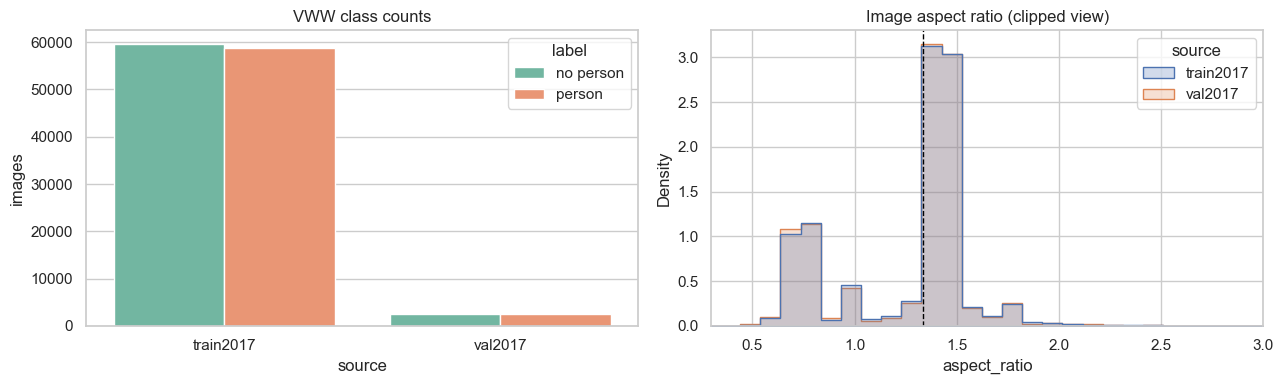

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.countplot(data=eda, x='source', hue='label', ax=axes[0], palette='Set2')
axes[0].set(title='VWW class counts', ylabel='images')
axes[0].legend(title='label', labels=['no person', 'person'])
sns.histplot(data=eda, x='aspect_ratio', hue='source', bins=60, element='step', stat='density', common_norm=False, ax=axes[1])
axes[1].axvline(4/3, color='black', linestyle='--', linewidth=1, label='4:3 sensor')
axes[1].set(xlim=(0.3, 3.0), title='Image aspect ratio (clipped view)')
plt.tight_layout()

## Person-scale distribution and threshold sensitivity

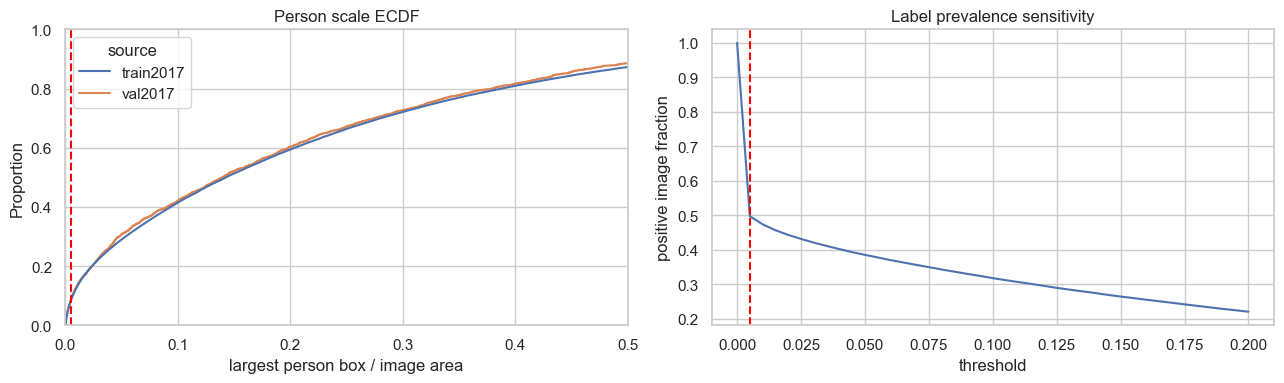

In [5]:
person_images = eda[eda['max_person_area_fraction'] > 0].copy()
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.ecdfplot(data=person_images, x='max_person_area_fraction', hue='source', ax=axes[0])
axes[0].axvline(threshold, color='red', linestyle='--', label=f'{threshold:.0%} rule')
axes[0].set(xlim=(0, 0.5), xlabel='largest person box / image area', title='Person scale ECDF')
thresholds = np.linspace(0, 0.2, 41)
sensitivity = pd.DataFrame({'threshold': thresholds, 'positive_rate': [(eda.max_person_area_fraction >= value).mean() for value in thresholds]})
sns.lineplot(data=sensitivity, x='threshold', y='positive_rate', ax=axes[1])
axes[1].axvline(threshold, color='red', linestyle='--')
axes[1].set(title='Label prevalence sensitivity', ylabel='positive image fraction')
plt.tight_layout()

## Qualitative label audit

A stratified grid makes the 0.5% boundary tangible and can expose surprising negatives before training.

000000491502.jpg: 100%|██████████| 109k/109k [00:00<00:00, 230kB/s]
000000068482.jpg: 100%|██████████| 252k/252k [00:02<00:00, 112kB/s]
000000455660.jpg: 100%|██████████| 165k/165k [00:01<00:00, 102kB/s]
000000266023.jpg: 100%|██████████| 224k/224k [00:00<00:00, 322kB/s]
000000024706.jpg: 100%|██████████| 94.1k/94.1k [00:00<00:00, 203kB/s]
000000385115.jpg: 100%|██████████| 137k/137k [00:01<00:00, 96.0kB/s]
000000233706.jpg: 100%|██████████| 201k/201k [00:00<00:00, 281kB/s]
000000373395.jpg: 100%|██████████| 221k/221k [00:00<00:00, 258kB/s]


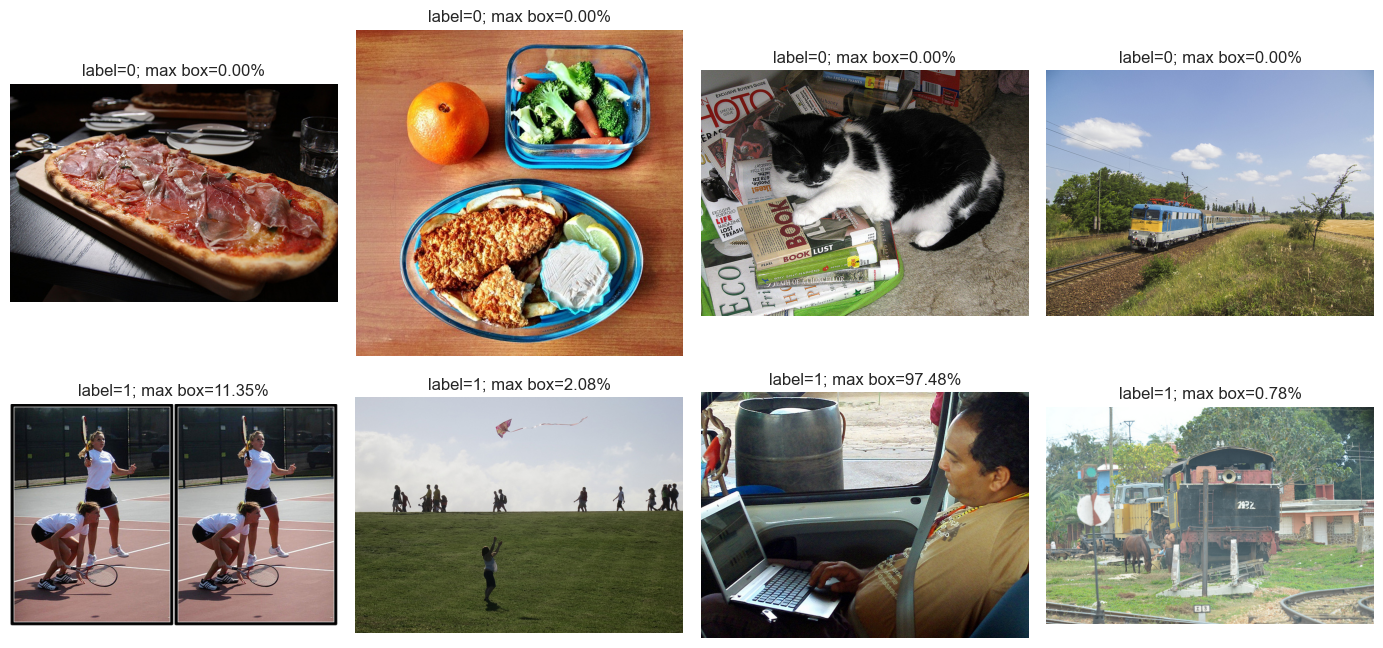

In [6]:
from PIL import Image
from vww_esp32.data import coco_download_url, download_file

examples = pd.concat([group.sample(n=4, random_state=42) for _, group in eda.groupby('label')])
figure, axes = plt.subplots(2, 4, figsize=(14, 7))
for axis, row in zip(axes.flat, examples.itertuples()):
    url = coco_download_url(row.coco_url)
    local = paths['raw'] / 'eda_samples' / row.file_name
    download_file(url, local)
    axis.imshow(Image.open(local).convert('RGB'))
    axis.set_title(f"label={row.label}; max box={row.max_person_area_fraction:.2%}")
    axis.axis('off')
plt.tight_layout()

## Sampling-bias checks

Resolution, aspect ratio, license mix, person count, and scale can become shortcuts. These tables identify strata to revisit during error analysis.

In [7]:
pd.crosstab(pd.cut(eda.aspect_ratio, [0, .8, 1.2, 1.6, 10]), eda.label, normalize='index').rename(columns={0: 'negative_rate', 1: 'positive_rate'}).style.format('{:.1%}')

label,negative_rate,positive_rate
aspect_ratio,,
"(0.0, 0.8]",47.2%,52.8%
"(0.8, 1.2]",49.9%,50.1%
"(1.2, 1.6]",51.2%,48.8%
"(1.6, 10.0]",52.9%,47.1%


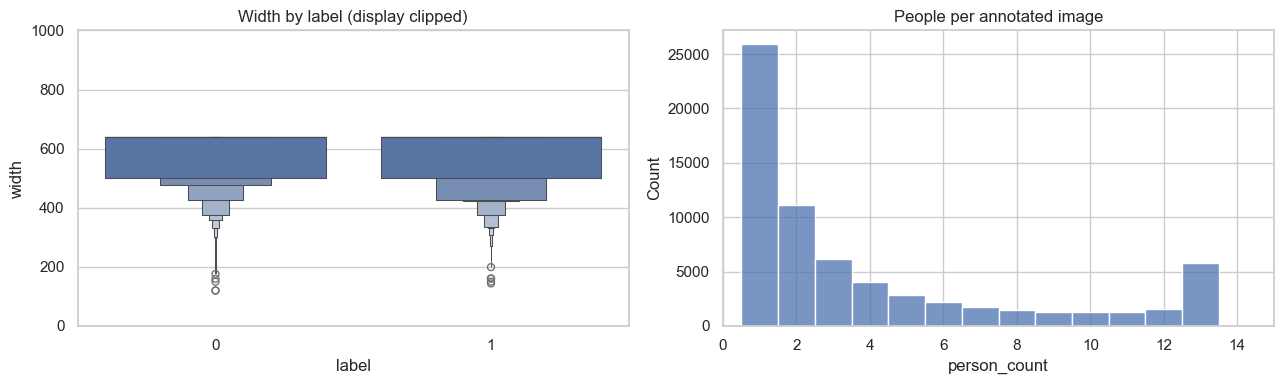

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.boxenplot(data=eda.sample(min(20000, len(eda)), random_state=42), x='label', y='width', ax=axes[0])
axes[0].set(ylim=(0, 1000), title='Width by label (display clipped)')
sns.histplot(data=person_images, x='person_count', bins=range(1, 16), discrete=True, ax=axes[1])
axes[1].set(xlim=(0, 15), title='People per annotated image')
plt.tight_layout()

## Findings to carry forward

Write observations here after execution. At minimum address class prior, the fraction of ambiguous small-person images, geometry shift from resizing, and whether the sampled training balance differs from deployment prevalence.